# Prédiction du score d'addiction à l'alcool
## Modèles de Machine Learning (comparaison et analyse) 

**Dataset :** Students-mat   
**Variable cible :** `Dalc` — Nombre de verres d'alcool par jour

Ce notebook charge les données, fait le preprocessing, puis appelle chaque modèle depuis le dossier `models/`.  
Il compare ensuite les résultats et propose un exemple d'application concret.

In [5]:
#%pip install scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score



from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBRegressor

In [6]:
from models.ACP import ACP
from models.encoder import labelEncoder, oneHotEncoder
from sklearn.model_selection import StratifiedKFold, cross_validate

df = pd.read_csv("BDD_initial/student-mat.csv", sep=",", index_col=0)


In [3]:
df.info()

<class 'pandas.DataFrame'>
Index: 395 entries, GP to MS
Data columns (total 32 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   sex         395 non-null    str  
 1   age         395 non-null    int64
 2   address     395 non-null    str  
 3   famsize     395 non-null    str  
 4   Pstatus     395 non-null    str  
 5   Medu        395 non-null    int64
 6   Fedu        395 non-null    int64
 7   Mjob        395 non-null    str  
 8   Fjob        395 non-null    str  
 9   reason      395 non-null    str  
 10  guardian    395 non-null    str  
 11  traveltime  395 non-null    int64
 12  studytime   395 non-null    int64
 13  failures    395 non-null    int64
 14  schoolsup   395 non-null    str  
 15  famsup      395 non-null    str  
 16  paid        395 non-null    str  
 17  activities  395 non-null    str  
 18  nursery     395 non-null    str  
 19  higher      395 non-null    str  
 20  internet    395 non-null    str  
 21  romantic 

## 2 - Chargement et preprocessing

On charge le dataset, séparons les données de la variable que l'on veut prédire et on convertit les variables textuelles en nombres avec `LabelEncoder` et `oneHotEncoder`.

Ensuite on sépare les données en 80% entraînement / 20% test.

In [7]:
from models.ACP import ACP_v2
from models.encoder import labelEncoder, oneHotEncoder
from sklearn.model_selection import ShuffleSplit
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

df = pd.read_csv("BDD_initial/student-mat.csv", sep=",", index_col=0)

y = df['Dalc']
X_raw = df.drop(columns=['Dalc', 'Walc'])

cat_cols = X_raw.select_dtypes(include='object').columns.tolist()
num_cols = X_raw.select_dtypes(exclude='object').columns.tolist()

X_le = X_raw.copy()
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_le[col] = le.fit_transform(X_raw[col])
    label_encoders[col] = le
#print(X_le.head())


preprocessor = ColumnTransformer(transformers=[
        ("ohe", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)   
    ]
)

X_ohe = pd.DataFrame(
    preprocessor.fit_transform(X_raw),
    index=X_raw.index
)
#print(X_ohe.head())

# ACP

# Train et test set — même random_state pour comparer sur les mêmes données
X_train_le,  X_test_le,  y_train_le, y_test_le = train_test_split(X_le,  y, test_size=0.2, random_state=45)
X_train_ohe, X_test_ohe, y_train_ohe, y_test_ohe= train_test_split(X_ohe, y, test_size=0.2, random_state=45)

X_train_acp, X_test_acp = ACP_v2(X_train_ohe, X_test_ohe, n_components=0.9)

print('X_le  shape:', X_le.shape)
print('X_ohe shape:', X_ohe.shape)
print('Train / Test LE :', X_train_le.shape, '/', X_test_le.shape)
print('Train / Test OHE :', X_train_ohe.shape, '/', X_test_ohe.shape)
print('Train / Test ACP :', X_train_acp.shape, X_test_acp.shape)


#Nous préférons utiliser ShuffleSplit pour faire du cross-validation.
N_SPLITS   = 5   
TEST_SIZE  = 0.2
ss = ShuffleSplit(n_splits=N_SPLITS, test_size=TEST_SIZE, random_state=100)

splits_le = [(train_idx, test_idx) for train_idx, test_idx in ss.split(X_le, y)]
print(f'Train / Test le : {len(splits_le[0][0])} / {len(splits_le[0][1])}  ({N_SPLITS} splits)')
splits_ohe = [(train_idx, test_idx) for train_idx, test_idx in ss.split(X_le, y)]
print(f'Train / Test ohe : {len(splits_ohe[0][0])} / {len(splits_ohe[0][1])}  ({N_SPLITS} splits)')
splits_acp = [(train_idx, test_idx) for train_idx, test_idx in ss.split(X_le, y)]
print(f'Train / Test acp : {len(splits_acp[0][0])} / {len(splits_acp[0][1])}  ({N_SPLITS} splits)')


X_le  shape: (395, 30)
X_ohe shape: (395, 55)
Train / Test LE : (316, 30) / (79, 30)
Train / Test OHE : (316, 55) / (79, 55)
Train / Test ACP : (316, 28) (79, 28)
Train / Test le : 316 / 79  (5 splits)
Train / Test ohe : 316 / 79  (5 splits)
Train / Test acp : 316 / 79  (5 splits)


C:\Users\sidsm\AppData\Local\Temp\ipykernel_8332\3268714943.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_raw.select_dtypes(include='object').columns.tolist()


## 3. Entraînement des modèles

Chaque modèle est dans un fichier séparé dans `models/`.  
La fonction `run(X_train, X_test, y_train, y_test)` retourne un dictionnaire avec les métriques.

Tous les modèles sont présents en 2 versions : 
la version initial avec GridSearchCV est la meilleur mais peut prendre plusieurs minutes, la version 2 avec RandomizedSearchCV est plus courte mais moins précise. 

> **Pour ajouter un modèle** : importer sa fonction `run` et l'ajouter au dictionnaire `modeles`.

In [8]:

from models.random_forest_rgs_v2 import run as run_rf
from models.xgboost_rgs_v2 import run as run_xgb_rgs
from models.knn_rgs import run as run_knn
from models.naive_bayes_rgs_v2 import run as run_nb_rgs
from models.xgboost import run as run_xgb

modeles = {
    'KNN'          : run_knn,
    'XGBoost'      : run_xgb,
    'Naive Bayes rgs'  : run_nb_rgs,
    'Random Forest': run_rf,
}

resultats = {}
for nom, run_fn in modeles.items():
    print(f'Entraînement : {nom}...')

    resultats_temp_le = []
    best_score=-np.inf
    best_args=None

    for i, (train_idx, test_idx) in enumerate(splits_le):
        X_train_le,  X_test_le  = X_le.iloc[train_idx],  X_le.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx],     y.iloc[test_idx]

        res = run_fn(X_train_le,  X_test_le,  y_train, y_test)
        resultats_temp_le.append(res['optimized']['r2'])
        if(res['optimized']['r2'] > best_score):
            best_score = res['optimized']['r2']
            best_args = res
        
    resultats[f'{nom} (LE)']  = best_args
    print(f"  LE  R²: {resultats[f'{nom} (LE)']['optimized']['r2']:.4f}")
    print(f"  LE  R² (moyenne sur splits) : {np.mean(resultats_temp_le):.4f}")
    resultats_temp_ohe = []
    resultats_temp_acp = []

    best_score_ohe=-np.inf
    best_score_acp=-np.inf
    best_args_ohe=None
    best_args_acp=None

    for i, (train_idx, test_idx) in enumerate(splits_ohe):
        
        X_train_ohe, X_test_ohe = X_ohe.iloc[train_idx], X_ohe.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx],     y.iloc[test_idx]
        
        X_train_acp, X_test_acp = ACP_v2(X_train_ohe, X_test_ohe, n_components=0.9)

        res_ohe = run_fn(X_train_ohe,  X_test_ohe,  y_train, y_test)
        res_acp = run_fn(X_train_acp,  X_test_acp,  y_train, y_test)

        resultats_temp_ohe.append(res_ohe['optimized']['r2'])
        if(res_ohe['optimized']['r2'] > best_score_ohe):
            best_score_ohe = res_ohe['optimized']['r2']
            best_args_ohe = res_ohe
        resultats_temp_acp.append(res_acp['optimized']['r2'])
        if(res_acp['optimized']['r2'] > best_score_acp):
            best_args_acp = res_acp
            best_score_acp= res_acp['optimized']['r2']

    resultats[f'{nom} (OHE)'] = best_args_ohe
    resultats[f'{nom} (ACP)'] = best_args_acp

    print(f"  OHE R²: {resultats[f'{nom} (OHE)']['optimized']['r2']:.4f}")
    print(f"  OHE R² (moyenne sur splits) : {np.mean(resultats_temp_ohe):.4f}")
    print(f"  ACP R²: {resultats[f'{nom} (ACP)']['optimized']['r2']:.4f}")
    print(f"  ACP  R² (moyenne sur splits) : {np.mean(resultats_temp_acp):.4f}")

print('\nTerminé.')


Entraînement : KNN...
  LE  R²: 0.2840
  LE  R² (moyenne sur splits) : 0.0539
  OHE R²: 0.1621
  OHE R² (moyenne sur splits) : -0.0139
  ACP R²: 0.1672
  ACP  R² (moyenne sur splits) : -0.0802
Entraînement : XGBoost...
  LE  R²: 0.2160
  LE  R² (moyenne sur splits) : 0.0887
  OHE R²: 0.1005
  OHE R² (moyenne sur splits) : 0.0486
  ACP R²: 0.1284
  ACP  R² (moyenne sur splits) : 0.0119
Entraînement : Naive Bayes rgs...
  LE  R²: -0.4122
  LE  R² (moyenne sur splits) : -1.3804
  OHE R²: -3.2159
  OHE R² (moyenne sur splits) : -6.9306
  ACP R²: -0.0763
  ACP  R² (moyenne sur splits) : -0.1670
Entraînement : Random Forest...
  LE  R²: 0.2599
  LE  R² (moyenne sur splits) : 0.1330
  OHE R²: 0.2175
  OHE R² (moyenne sur splits) : 0.1011
  ACP R²: 0.1435
  ACP  R² (moyenne sur splits) : 0.0051

Terminé.


On choisit de conserver le modèle d'apprentissage KNN 

In [ ]:
from sklearn.ensemble import VotingRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression

# 1. Extraction des vrais modèles (estimateurs Scikit-Learn) 
estimators_acp = [
    ('KNN', resultats['KNN (LE)']['model']),
    ('xgb', resultats['XGBoost (ACP)']['model']),
    ('rf', resultats['Random Forest (ACP)']['model'])
]

print('\nEntraînement des modèles d\'Ensemble...')

# 2. Voting Regressor (Fait la moyenne des prédictions)
model_voting = VotingRegressor(estimators=estimators_acp)

model_voting.fit(X_train_acp, y_train) 
score_voting_acp = model_voting.score(X_test_acp, y_test)

model_voting.fit(X_train_ohe, y_train_ohe) 
score_voting_ohe = model_voting.score(X_test_ohe, y_test)

model_voting.fit(X_train_le, y_train_le) 
score_voting_le = model_voting.score(X_test_le, y_test)

print(f"  Voting Regressor (ACP) R²: {score_voting_acp:.4f}")
print(f"  Voting Regressor (OHE) R²: {score_voting_ohe:.4f}")
print(f"  Voting Regressor (LE) R²: {score_voting_le:.4f}")

# 3. Stacking Regressor (Utilise un modèle final pour trancher)
model_stack = StackingRegressor(
    estimators=estimators_acp,
    final_estimator=LinearRegression(),
    cv=3 # Ajout de cv=3 pour accélérer l'entraînement interne
)
model_stack.fit(X_train_acp, y_train)
score_stacking_acp = model_stack.score(X_test_acp, y_test)

model_stack.fit(X_train_ohe, y_train) 
score_stacking_ohe = model_stack.score(X_test_ohe, y_test)

model_stack.fit(X_train_le, y_train) 
score_stacking_le = model_stack.score(X_test_le, y_test)

print(f"  Stacking Regressor (ACP) R²: {score_stacking_acp:.4f}")
print(f"  Stacking Regressor (OHE) R²: {score_stacking_ohe:.4f}")
print(f"  Stacking Regressor (LE) R²: {score_stacking_le:.4f}")


print('\nTerminé.')


Entraînement des modèles d'Ensemble...
  Voting Regressor (ACP) R²: 0.1668
  Voting Regressor (OHE) R²: 0.0803
  Voting Regressor (LE) R²: 0.0828
  Stacking Regressor (ACP) R²: 0.1474
  Stacking Regressor (OHE) R²: 0.1426
  Stacking Regressor (LE) R²: 0.1161

Terminé.


### 4 Entrainement d'une plus grande variété de modèles d'apprentissage


In [23]:
clf = DecisionTreeRegressor()
scores = cross_val_score(clf, X_ohe, y, cv=5)
scores.mean()
print("Scores OHE : ", scores)
print(scores.mean())

clf = DecisionTreeRegressor()
scores = cross_val_score(clf, X_le, y, cv=5)
scores.mean()
print("Scores LE : ", scores)
print(scores.mean())



Scores OHE :  [-0.52450791 -0.81939394 -0.36418793 -1.69488313 -0.27126437]
-0.7348474560640291
Scores LE :  [-0.57024315 -0.31666667 -0.5116677  -1.66993051 -0.43990148]
-0.701681901868985


Les modèles de régressions ne sont ici pas performant, particulièrement en comparaison avec les modèles de classifications. 

In [ ]:
def nbr_estimator_model(model,n_estim=100):
    best = 0
    best_k=0
    for k in range (1,n_estim,1):
        model_train = model(n_estimators=k)
        model_train.fit(X_train_acp, y_train)
        score = model_train.score(X_test_acp, y_test)
        if(best<score):
            best=score
            best_k=k
    print("best : ",best_k,best)
    return [best_k,best]



In [ ]:
resultats[f'KNN (LE)']['optimized']['best_params']

{'weights': 'distance',
 'n_neighbors': 9,
 'metric': 'manhattan',
 'algorithm': 'ball_tree'}

In [ ]:
resultats[f'xgboost (LE)']['optimized']['best_params']

KeyError: 'xgboost rgs (LE)'

In [ ]:
resultats[f'Random Forest (LE)']['optimized']['best_params']

In [27]:
from sklearn.ensemble import RandomForestRegressor 


modeles = {
    "decision_tree_regressor": DecisionTreeRegressor(),
    "XGBRegressor":XGBRegressor(n_estimators=100,random_state=42),
    "decision_tree_classifier": DecisionTreeClassifier(),
    "random_forest_regression": RandomForestRegressor(n_estimators=200, max_depth=None, min_samples_split= 2,min_samples_leaf= 2),
    "random_forest_classifier": RandomForestClassifier(n_estimators=10, max_depth=3),
    "logistic_regression": LogisticRegression(max_iter=1000),
    "gaussian_nb": GaussianNB(),
    "sgd_classifier": SGDClassifier(random_state=1),
    "knn_classifier": KNeighborsClassifier(n_neighbors=9,algorithm='ball_tree', weights='distance', metric='manhattan'),
    "bagging_classifier": BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=10)
}

best=None
score_Best=-np.inf
list_model_voting = []
for nom, model in modeles.items():
    model.fit(X_train_acp, y_train)
    score_model = model.score(X_test_acp,y_test)
    print(f"{nom} : {score_model:.4f}")
    if score_model >score_Best:
        Best=model
        score_Best=score_model
    if(score_model >0.5):
        list_model_voting.append((nom, model))
        
model_0 = VotingClassifier(list_model_voting,
                          voting='hard')
model_0.fit(X_train_acp, y_train)
model_0.score(X_test_acp, y_test)

model_stack = StackingClassifier(list_model_voting,
                             final_estimator=model_0)
model_stack.fit(X_train_acp, y_train)
model_stack.score(X_test_acp, y_test)

if(score_Best>model_0.score(X_train_acp, y_train)):
    best=model_0
if(score_Best>model_stack.score(X_test_acp, y_test)):
    best=model_stack
print(f"\n\nMeilleur modèle : {best.__class__.__name__} avec un score de {score_Best:.4f}\n\n")

decision_tree_regressor : -1.6450
XGBRegressor : -0.0106
decision_tree_classifier : 0.5949
random_forest_regression : 0.1262
random_forest_classifier : 0.6329
logistic_regression : 0.6582
gaussian_nb : 0.6456
sgd_classifier : 0.6456
knn_classifier : 0.6329
bagging_classifier : 0.5949


Meilleur modèle : StackingClassifier avec un score de 0.6582




c:\MAMP\htdocs\Addiction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 4. Tableau comparatif

On compare les modèles sur trois métriques :
- **R²** : proportion de variance expliquée (plus c'est proche de 1, mieux c'est)
- **MAE** : erreur moyenne en points de score
- **RMSE** : similaire au MAE, mais pénalise plus les grandes erreurs

In [11]:
rows = []
for nom, res in resultats.items():
    opt = res['optimized']
    rows.append({
        'Modèle': nom,
        'R²'    : round(opt['r2'],   4),
        'MAE'   : round(opt['mae'],  4),
        'RMSE'  : round(opt['rmse'], 4),
    })

df_comparaison = pd.DataFrame(rows).sort_values('R²', ascending=False).set_index('Modèle')
df_comparaison

,R²,MAE,RMSE
Modèle,,,
KNN (LE),0.2840,0.4928,0.7234
Random Forest (LE),0.2599,0.5743,0.7355
Random Forest (OHE),0.2175,0.5759,0.7563
XGBoost (LE),0.2160,0.5798,0.7570
KNN (ACP),0.1672,0.5035,0.7214
KNN (OHE),0.1621,0.5363,0.7826
Random Forest (ACP),0.1435,0.5688,0.7316
XGBoost (ACP),0.1284,0.5704,0.7380
XGBoost (OHE),0.1005,0.5681,0.7497


## 5. Visualisation des métriques

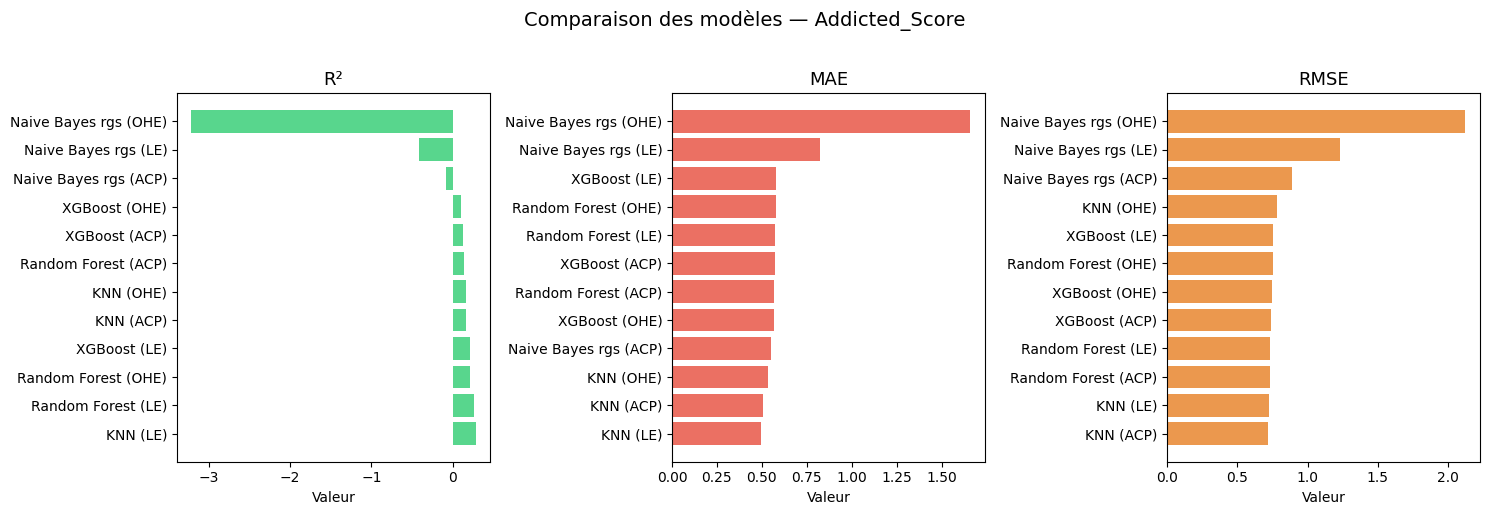

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [('R²', '#2ecc71', False), ('MAE', '#e74c3c', True), ('RMSE', '#e67e22', True)]

for ax, (metric, color, ascending) in zip(axes, metrics):
    vals = df_comparaison[metric].sort_values(ascending=ascending)
    ax.barh(vals.index, vals.values, color=color, alpha=0.8)
    ax.set_title(metric, fontsize=13)
    ax.set_xlabel('Valeur')

plt.suptitle('Comparaison des modèles — Addicted_Score', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Exemple d'application

On crée un profil d'étudiant fictif et on demande au modèle de prédire son score d'addiction.  
Les variables catégorielles sont encodées avec les mêmes `LabelEncoder` utilisés à l'étape 2.

In [ ]:

# exemple d'un étudiant fictif
etudiant = {
    'sex'        : 'F',       
    'age'        : 17,        
    'address'    : 'U',       
    'famsize'    : 'GT3',     
    'Pstatus'    : 'T',       
    'Medu'       : 3,         
    'Fedu'       : 2,         
    'Mjob'       : 'other',   
    'Fjob'       : 'other',   
    'guardian'   : 'mother',  
    'famrel'     : 4,         
    'famsup'     : 'yes',     

    'reason'     : 'course',  
    'traveltime' : 1,         
    'studytime'  : 2,         
    'failures'   : 0,         
    'schoolsup'  : 'no',     
    'paid'       : 'no',     
    'nursery'    : 'yes',     
    'higher'     : 'yes',     
    'absences'   : 4,        
    'G1'         : 11,        
    'G2'         : 11,      
    'G3'         : 11,        

    'internet'   : 'yes',     
    'activities' : 'yes',     
    'romantic'   : 'no',      
    'freetime'   : 3,       
    'goout'      : 3,         
    'health'     : 4,        
}

# trouve le meilleur modèle selon R²
meilleur_cle = "KNN (LE)"
meilleur_r2  = resultats[meilleur_cle]['optimized']['r2']

etudiant_df = pd.DataFrame([etudiant])
print(meilleur_cle)
# encodage
etudiant_enc = {}
for col, val in etudiant.items():
    if col in label_encoders:
        etudiant_enc[col] = label_encoders[col].transform([val])[0]
    else:
        etudiant_enc[col] = val


if '(LE)' in meilleur_cle:
    X_etudiant = pd.DataFrame([etudiant_enc])[X_le.columns]
elif '(ACP)' in meilleur_cle:
    etudiant_ohe = pd.DataFrame(
        preprocessor.transform(etudiant_df),
        columns=X_ohe.columns
    )
    X_etudiant, _ = ACP_v2(etudiant_ohe, etudiant_ohe)
else:
    # ← preprocessor au lieu de oneHotEncoder
    X_etudiant = pd.DataFrame(
        preprocessor.transform(etudiant_df.copy()),
        columns=X_ohe.columns
    )

    print("ttt",X_etudiant.shape)

score_predit = resultats[meilleur_cle]['model'].predict(X_etudiant)[0]

print("=== Profil de l'étudiant ===")
for k, v in etudiant.items():
    print(f"  {k:<35} : {v}")

print(f"\n Modèle utilisé : {meilleur_cle}  (R² = {meilleur_r2:.4f})")
print(f" Score prédit   : {score_predit:.2f} / 5")


KNN (LE)
=== Profil de l'étudiant ===
  sex                                 : F
  age                                 : 17
  address                             : U
  famsize                             : GT3
  Pstatus                             : T
  Medu                                : 3
  Fedu                                : 2
  Mjob                                : other
  Fjob                                : other
  guardian                            : mother
  famrel                              : 4
  famsup                              : yes
  reason                              : course
  traveltime                          : 1
  studytime                           : 2
  failures                            : 0
  schoolsup                           : no
  paid                                : no
  nursery                             : yes
  higher                              : yes
  absences                            : 4
  G1                                  : 11
  G2    

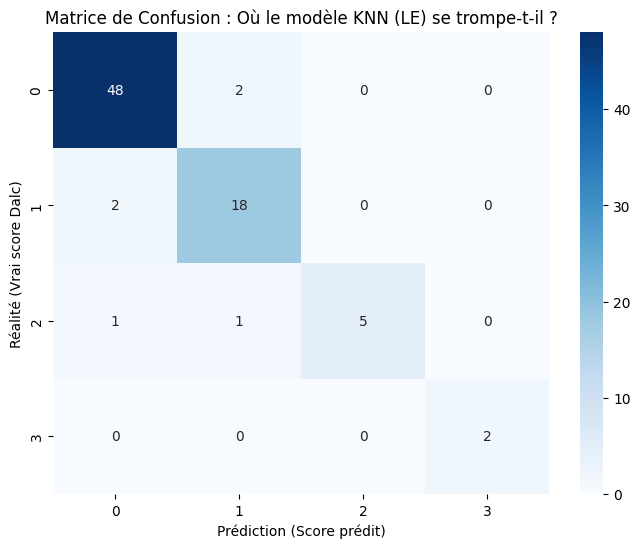

              precision    recall  f1-score   support

           1       0.94      0.96      0.95        50
           2       0.86      0.90      0.88        20
           3       1.00      0.71      0.83         7
           4       1.00      1.00      1.00         2

    accuracy                           0.92        79
   macro avg       0.95      0.89      0.92        79
weighted avg       0.93      0.92      0.92        79



In [31]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

if '(LE)' in meilleur_cle:
    X_test_final = X_test_le
    y_test_final = y_test
elif '(OHE)' in meilleur_cle:
    print(X_test_ohe.shape, y_test_ohe.shape)
    X_test_final = X_test_ohe
    y_test_final = y_test_ohe
else:
    X_test_final = X_test_acp
    y_test_final = y_test

best_model = resultats[meilleur_cle]['model']
y_pred_final = best_model.predict(X_test_final)

y_pred_classes = np.round(y_pred_final).astype(int)
y_test_classes = np.round(y_test_final).astype(int)

# 4. Création de la matrice de confusion
conf_matrix = confusion_matrix(y_test_classes, y_pred_classes)

# 5. Affichage du graphique
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Réalité (Vrai score Dalc)')
plt.xlabel('Prédiction (Score prédit)')
plt.title(f'Matrice de Confusion : Où le modèle {meilleur_cle} se trompe-t-il ?')
plt.show()

# 6. Rapport de classification
print(classification_report(y_test_classes, y_pred_classes))

Cette matrice confirme les analyses que nous avons déjà effectuées dans le notebook de prévisualisation des données : notre jeu de donnée contient une grande majorité de valeur 0 et 1 pour la variable Dalc, ce qui fait que notre modèle atteint un score d'accuracy de 0.92 en prédisant presque uniquement des 0 et 1. 

## 7. Conclusion

Ce notebook compare les modèles de régression entraînés sur le dataset `student-mat`.  
Le meilleur modèle est sélectionné selon le R² le plus élevé et le MAE/RMSE les plus faibles.

Cependant, les résultats de nos modèles dépendent de la séparation de nos données en train set et test set. En entraînant d'autres variables et en testant d'autres, nos modèles peuvent se montrer plus ou moins performant. 

C'est pour cela que nous avons effectué une moyenne des R² obtenus, bien que nous ayons décidé de garder le modèle ayant obtenu le meilleur résultat : KNN avec comme encoder LabelEncoder. 


## 8/ Création du fichier .pkl du meilleur modèle

In [33]:
resultats[f'KNN (LE)']['optimized']['best_params']

{'weights': 'distance',
 'n_neighbors': 9,
 'metric': 'manhattan',
 'algorithm': 'ball_tree'}

In [34]:
import joblib
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import ShuffleSplit
from sklearn.metrics import r2_score

df = pd.read_csv("BDD_initial/student-mat.csv", sep=",", index_col=0)
y  = df['Dalc']
X_raw = df.drop(columns=['Dalc', 'Walc']).copy()

cat_cols = X_raw.select_dtypes(include='object').columns.tolist()
num_cols = X_raw.select_dtypes(exclude='object').columns.tolist()

X_le = X_raw.copy()
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_le[col] = le.fit_transform(X_raw[col])
    label_encoders[col] = le

print(f"Colonnes catégorielles encodées : {cat_cols}")
print(f"Colonnes numériques conservées  : {num_cols}")
print(f"Shape X_le : {X_le.shape}")


best_model = resultats["KNN (LE)"]['model']


joblib.dump({
    'model'         : best_model,
    'label_encoders': label_encoders,   # fitté sur X_raw complet
    'cat_cols'      : cat_cols,         # colonnes à encoder
    'num_cols'      : num_cols,         # colonnes à laisser intactes
    'feature_order' : X_le.columns.tolist(),  # ordre exact attendu par le modèle
}, "model_alcool.pkl")

print("Modèle sauvegardé : model_alcool.pkl")

Colonnes catégorielles encodées : ['sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Colonnes numériques conservées  : ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'health', 'absences', 'G1', 'G2', 'G3']
Shape X_le : (395, 30)
Modèle sauvegardé : model_alcool.pkl


C:\Users\sidsm\AppData\Local\Temp\ipykernel_6300\2796246515.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_raw.select_dtypes(include='object').columns.tolist()
